# Chapter 15 — Stress-Strain Relationships
### *Modern Strain Gage Technology* — Companion Notebook

**A strain gage reads deformation, but the engineer wants stress — and the entire bridge between the two, for an isotropic elastic solid, is just two numbers: Young's modulus *E* and Poisson's ratio *ν*.**

Companion notebook to Chapter 15 — Stress–Strain Relationships.

The relationship between stress and strain is where material science meets measurement. For an isotropic linear elastic material, six independent stress components produce six independent strain components through a 6×6 compliance matrix — but because of symmetry and isotropy, the entire matrix is determined by just two constants: Young's modulus *E* and Poisson's ratio *ν*. Every other elastic constant (shear modulus *G*, bulk modulus *K*, the Lamé constants) follows algebraically.

This matters for strain gage practice in two ways. First, a gage reads strain — but engineers usually want stress, and the conversion requires knowing the elastic constants of the specimen material. Second, the choice between **plane stress** and **plane strain** assumptions changes the computed stress from the same strain reading; getting that choice wrong can introduce errors of 10–20% in the inferred stress even when the measured strain is perfectly accurate.

**This notebook demonstrates:**
1. The 3D compliance matrix and derived elastic constants for a user-specified *E* and *ν*
2. The spread of handbook moduli (tension and compression) around the round values used in design, and what it does to a stress computed from a perfect strain reading
3. A numerical comparison of plane stress vs. plane strain strain components for the same applied load

In [1]:
# Colab setup: install dependencies (uncomment on a fresh Colab runtime)
# !pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures generated here are written to this directory; the book includes
# these exact files, so do not change the output path or filenames.
OUT_DIR = Path("../src/media/ch15")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — The Compliance Matrix (Isotropic Material)

The compliance matrix **S** encodes the complete linear elastic behavior of an isotropic material: strain equals compliance times stress, {ε} = [S]{σ}. For an isotropic solid, the matrix has a characteristic block structure — the normal-stress terms are coupled by ν (Poisson contraction), while the shear terms are completely decoupled and governed by G = E / 2(1+ν).

The worked example below applies 100 MPa of uniaxial tension in the x-direction and shows all six resulting strain components. Two things to notice: ε_x is positive (extension in the load direction) while ε_y and ε_z are negative and equal to −ν·ε_x (Poisson contraction). All three shear strains are zero, as expected for a principal load direction. This is the calculation a strain gage analyst performs in reverse — given measured ε_x, ε_y from a two-element rosette on a free surface, recover σ_x and σ_y.

In [2]:
# --- Material properties (edit these) ---
E_GPa = 200.0   # Young's modulus, GPa
NU    = 0.29    # Poisson's ratio (dimensionless)

E_MPa = E_GPa * 1e3  # work in MPa, so stresses in MPa yield strains directly


def elastic_constants(E, nu):
    """Return the derived isotropic elastic constants (G, K, lambda) from (E, nu).

    G is the shear modulus, K the bulk modulus, and lambda Lame's first
    constant. All three share the same pressure units as the input E.
    """
    G = E / (2 * (1 + nu))
    K = E / (3 * (1 - 2 * nu))
    lame_lambda = E * nu / ((1 + nu) * (1 - 2 * nu))
    return G, K, lame_lambda


def compliance_matrix(E, nu):
    """Build the 6x6 isotropic compliance matrix S, where {eps} = S @ {sigma}.

    Voigt ordering is [xx, yy, zz, xy, xz, yz]. Normal-stress terms are
    coupled by nu (Poisson contraction); the three shear rows are decoupled
    and governed by G = E / (2(1 + nu)), using engineering shear strain.
    """
    G = E / (2 * (1 + nu))
    return np.array([
        [ 1/E,  -nu/E, -nu/E,   0,   0,   0],
        [-nu/E,  1/E,  -nu/E,   0,   0,   0],
        [-nu/E, -nu/E,  1/E,    0,   0,   0],
        [   0,     0,     0,  1/G,   0,   0],
        [   0,     0,     0,    0, 1/G,   0],
        [   0,     0,     0,    0,   0, 1/G],
    ])


G, K, lame_lambda = elastic_constants(E_MPa, NU)
print(f"Input:  E = {E_GPa} GPa,  ν = {NU}")
print(f"Derived: G = {G/1e3:.2f} GPa  (shear modulus)")
print(f"         K = {K/1e3:.2f} GPa  (bulk modulus)")
print(f"         λ = {lame_lambda/1e3:.2f} GPa  (Lamé 1st constant)")
print()

S = compliance_matrix(E_MPa, NU)

# Worked example: uniaxial tension applied along x
UNIAXIAL_STRESS_MPa = 100.0
sigma_vec = np.array([UNIAXIAL_STRESS_MPa, 0, 0, 0, 0, 0])  # [σx,σy,σz,τxy,τxz,τyz]
eps_vec = S @ sigma_vec
labels = ['ε_x', 'ε_y', 'ε_z', 'γ_xy', 'γ_xz', 'γ_yz']
print(f"Uniaxial tension σ_x = {UNIAXIAL_STRESS_MPa:.0f} MPa:")
for lbl, val in zip(labels, eps_vec):
    print(f"  {lbl:6s} = {val*1e6:8.2f} με")

Input:  E = 200.0 GPa,  ν = 0.29
Derived: G = 77.52 GPa  (shear modulus)
         K = 158.73 GPa  (bulk modulus)
         λ = 107.05 GPa  (Lamé 1st constant)

Uniaxial tension σ_x = 100 MPa:
  ε_x    =   500.00 με
  ε_y    =  -145.00 με
  ε_z    =  -145.00 με
  γ_xy   =     0.00 με
  γ_xz   =     0.00 με
  γ_yz   =     0.00 με


---
## 2 — Which Modulus? The Handbook Spread Behind a Perfect Strain Reading

A strain gage reports strain; the stress comes from multiplying by a modulus somebody chose. The round numbers carried into design work, 70 GPa for aluminum and 200 GPa for steel, are not the numbers in the design handbook, and the handbook itself lists two moduli for each alloy: one in tension ($E$) and a slightly higher one in compression ($E_c$). MIL-HDBK-5J presents both as *typical* values, not statistically based minimums like its strength allowables.

The chart below takes the handbook values for four aluminum products and one precipitation-hardening stainless steel and plots each as a percentage difference from the generic round value. Because $\sigma = E\varepsilon$, that percentage is also the error in a stress computed with the generic modulus from a strain reading that is itself perfect. The shaded band is the 1–2 % uncertainty that NPL's *Good Practice Guide No. 98* says careful modulus measurement can reach; most of the handbook spread lies outside it.

Sources: MIL-HDBK-5J (31 January 2003; the last edition, continued by the FAA as MMPDS), Tables 3.6.2.0(b1) (6061 sheet), 3.7.6.0(b1) (7075 sheet), 3.2.3.0(d) (bare 2024 sheet and plate, all tempers), 2.6.9.0(b) (17-4PH). Values there are in units of 10³ ksi; 1 ksi = 6.894757 MPa.

Material                      E (GPa)  Ec (GPa)  E vs generic  Ec vs generic
6061 Al sheet                    68.3      69.6         -2.5%          -0.5%
7075 Al sheet                    71.0      72.4         +1.5%          +3.4%
2024 Al sheet (<6.35 mm)         72.4      73.8         +3.4%          +5.4%
2024 Al plate (≥6.35 mm)         73.8      75.2         +5.4%          +7.4%
17-4PH stainless                196.5     206.8         -1.7%          +3.4%

2024 plate, eps = -1,480 ue:  generic 70 GPa -> -103.6 MPa;  handbook Ec 75.2 GPa -> -111.3 MPa  (+7.4%)


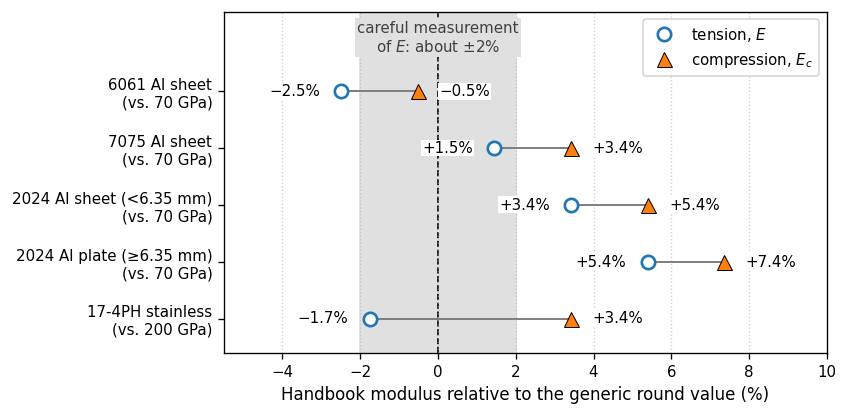

In [3]:
# Handbook moduli (MIL-HDBK-5J), in 10^3 ksi: (E in tension, Ec in compression)
KSI_TO_GPA = 6.894757e-3          # 1 ksi = 6.894757 MPa
handbook = [
    # label,                          E,    Ec,   generic modulus (GPa)
    ('6061 Al sheet',                 9.9, 10.1,  70.0),
    ('7075 Al sheet',                10.3, 10.5,  70.0),
    ('2024 Al sheet (<6.35 mm)',     10.5, 10.7,  70.0),
    ('2024 Al plate (≥6.35 mm)',     10.7, 10.9,  70.0),
    ('17-4PH stainless',             28.5, 30.0, 200.0),
]

print(f"{'Material':28s} {'E (GPa)':>8s} {'Ec (GPa)':>9s} {'E vs generic':>13s} {'Ec vs generic':>14s}")
rows = []
for label, E_ksi, Ec_ksi, generic in handbook:
    E_gpa  = E_ksi  * 1e3 * KSI_TO_GPA
    Ec_gpa = Ec_ksi * 1e3 * KSI_TO_GPA
    dE  = 100 * (E_gpa  / generic - 1)
    dEc = 100 * (Ec_gpa / generic - 1)
    rows.append((label, E_gpa, Ec_gpa, dE, dEc, generic))
    print(f"{label:28s} {E_gpa:8.1f} {Ec_gpa:9.1f} {dE:+12.1f}% {dEc:+13.1f}%")

# Worked example from the chapter: a perfect -1,480 microstrain reading on 2024 plate
eps = -1480e-6
s_generic = 70.0e3 * eps
Ec_plate  = round(rows[3][2], 1)          # GPa, rounded as printed in the chapter
s_handbk  = Ec_plate * 1e3 * eps
print(f"\n2024 plate, eps = -1,480 ue:  generic 70 GPa -> {s_generic:.1f} MPa;"
      f"  handbook Ec {Ec_plate:.1f} GPa -> {s_handbk:.1f} MPa"
      f"  ({100*(s_handbk/s_generic-1):+.1f}%)")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.axvspan(-2, 2, color='0.88', zorder=0)
ax.text(0, len(rows) - 0.35, 'careful measurement\nof $E$: about $\\pm$2%',
        ha='center', va='bottom', fontsize=9, color='0.25',
        bbox=dict(facecolor='0.88', edgecolor='none', pad=1.5), zorder=4)
ax.axvline(0, color='black', lw=1.0, ls='--', zorder=1)
for i, (label, E_gpa, Ec_gpa, dE, dEc, generic) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.plot([dE, dEc], [y, y], color='0.5', lw=1.2, zorder=2)
    ax.plot(dE, y, marker='o', ms=8, mfc='white', mec='tab:blue', mew=1.6,
            ls='none', zorder=3, label='tension, $E$' if i == 0 else None)
    ax.plot(dEc, y, marker='^', ms=9, color='tab:orange', mec='black', mew=0.6,
            ls='none', zorder=3, label='compression, $E_c$' if i == 0 else None)
    lab = lambda v: f'{v:+.1f}%'.replace('-', '−')
    ax.text(max(dE, dEc) + 0.55, y, lab(dEc), va='center', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', pad=0.5), zorder=4)
    ax.text(min(dE, dEc) - 0.55, y, lab(dE), va='center', ha='right', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='none', pad=0.5), zorder=4)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] + f'\n(vs. {r[5]:.0f} GPa)' for r in rows][::-1], fontsize=9)
ax.set_ylim(-0.6, len(rows) + 0.4)
ax.set_xlim(-5.5, 10)
ax.set_xlabel('Handbook modulus relative to the generic round value (%)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=9, frameon=True)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig15_nb1_handbook_modulus_spread.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 3 — Plane Stress vs. Plane Strain

Surface strain gages always operate in a *plane stress* condition: because the free surface cannot carry a normal traction, σ_z = 0 at the surface where the gage is bonded. The three in-plane strain components are free to take whatever values the applied loads dictate, and the out-of-plane strain ε_z is nonzero (though unmeasured by the gage).

Contrast this with *plane strain*, which applies in the interior of a long structure constrained against axial deformation. There, ε_z = 0 by constraint, and σ_z is nonzero. Using a plane strain constitutive relation to interpret surface gage data — or vice versa — introduces systematic error in every computed stress component. The printed comparison below makes the magnitude of that error concrete for a typical biaxial stress state.

In [4]:
# Compare plane stress vs. plane strain for the SAME applied in-plane stresses.
#   Plane stress: σ_z = 0  → ε_z ≠ 0   (thin plates, free surfaces — where gages live)
#   Plane strain: ε_z = 0  → σ_z ≠ 0   (long or thick laterally constrained bodies)
E_STEEL_MPa = 200e3   # Young's modulus, MPa
NU_STEEL    = 0.29    # Poisson's ratio

# Applied in-plane stress state (MPa)
SIGMA_X = 100.0
SIGMA_Y = 50.0
TAU_XY  = 20.0


def plane_stress_strains(sx, sy, E, nu):
    """Normal strains for a plane-stress state (σ_z = 0); returns (ε_x, ε_y, ε_z).

    The out-of-plane strain ε_z is generally nonzero even though σ_z = 0.
    """
    ex = (sx - nu * sy) / E
    ey = (sy - nu * sx) / E
    ez = -nu / E * (sx + sy)
    return ex, ey, ez


def plane_strain_strains(sx, sy, E, nu):
    """Normal strains for a plane-strain state (ε_z = 0); returns (ε_x, ε_y, ε_z).

    Out-of-plane deformation is constrained, so ε_z is identically zero while
    an out-of-plane stress σ_z = nu(sx + sy) develops (not returned here).
    """
    ex = (1/E) * ((1 - nu**2) * sx - nu * (1 + nu) * sy)
    ey = (1/E) * ((1 - nu**2) * sy - nu * (1 + nu) * sx)
    ez = 0.0
    return ex, ey, ez


ex_ps, ey_ps, ez_ps = plane_stress_strains(SIGMA_X, SIGMA_Y, E_STEEL_MPa, NU_STEEL)
ex_pe, ey_pe, ez_pe = plane_strain_strains(SIGMA_X, SIGMA_Y, E_STEEL_MPa, NU_STEEL)

print(f"In-plane stresses: sx={SIGMA_X:.0f}, sy={SIGMA_Y:.0f}, txy={TAU_XY:.0f} MPa")
print(f"{'':20s} {'Plane stress':>14} {'Plane strain':>14}")
print(f"{'ε_x (με)':20s} {ex_ps*1e6:>14.2f} {ex_pe*1e6:>14.2f}")
print(f"{'ε_y (με)':20s} {ey_ps*1e6:>14.2f} {ey_pe*1e6:>14.2f}")
print(f"{'ε_z (με)':20s} {ez_ps*1e6:>14.2f} {ez_pe*1e6:>14.2f}")
print()
print("Strain gages on free surfaces measure plane stress conditions.")
print("The out-of-plane strain ε_z is not zero, but cannot be measured by a surface gage.")

In-plane stresses: sx=100, sy=50, txy=20 MPa
                       Plane stress   Plane strain
ε_x (με)                     427.50         364.43
ε_y (με)                     105.00          41.93
ε_z (με)                    -217.50           0.00

Strain gages on free surfaces measure plane stress conditions.
The out-of-plane strain ε_z is not zero, but cannot be measured by a surface gage.


---
## Where to take this next

These three cells are a starting point. A few concrete extensions:

- **Turn the plane-stress equations into a rosette solver.** Take three measured strains from a 0°/45°/90° rectangular rosette, compute the principal strains and their orientation, then apply the strain-to-stress relations (Eqs. 15.5–15.6) to recover σ_x, σ_y, and τ_xy. Check the result against a hand calculation for a known load.
- **Propagate uncertainty in *E* and *ν*.** The chapter warns that errors in the elastic constants feed straight into inferred stress. Wrap `plane_stress_strains` in a Monte Carlo loop — seed the generator with `np.random.default_rng(0)`, perturb *E* and *ν* within their datasheet tolerances, and plot the resulting spread in computed stress.
- **Quantify the plane-stress vs. plane-strain gap.** Sweep Poisson's ratio from 0.25 to 0.49 and plot the percentage difference between the two ε_x predictions for a fixed stress state — making concrete why the choice matters most for nearly incompressible materials.